Gregory_Cooper_Advanced_Big_Data_and_Data_Mining_Lab_III

In [2]:
import pandas as pd
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import seaborn as sns

#show data and put in dataframe
wine = load_wine()

df = pd.DataFrame(wine.data, columns = wine.feature_names)
print(df.head())


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [3]:
#Perform basic data exploration to examine the feature details and class distribution
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [4]:
df['target'] = wine.target


In [5]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

target
1    71
0    59
2    48
Name: count, dtype: int64
target
1    39.887640
0    33.146067
2    26.966292
Name: proportion, dtype: float64


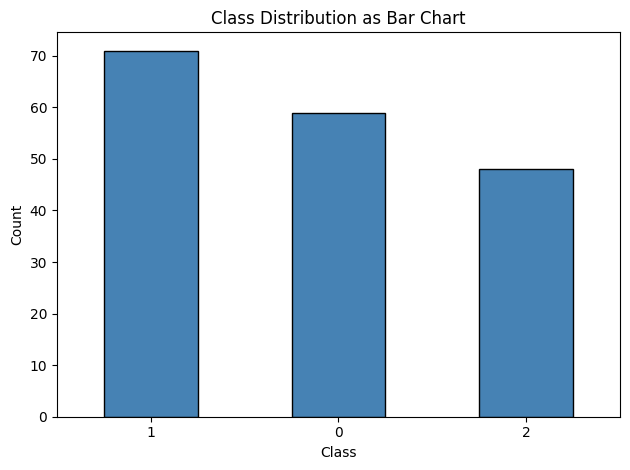

In [6]:
# Class Distribution as Bar chart
df['target'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution as Bar Chart')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



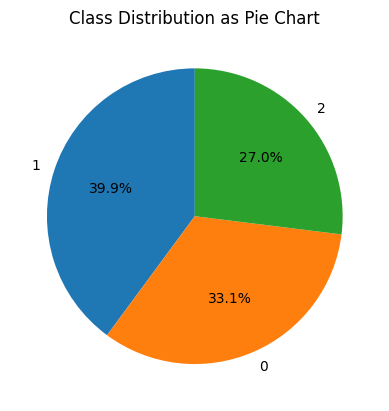

In [7]:
# Class Distribution as Pie chart
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution as Pie Chart')
plt.ylabel('')
plt.show()

In [8]:
#Basic Z-score Standardization
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=['target']) 
y = df['target']

# Initialize and fit the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [9]:
#Verify STD

print("Before scaling:")
print(X[X.columns].describe().loc[['mean', 'std']].round(2))

print("\nAfter scaling:")
X_scaled_df = pd.DataFrame(X_scaled)
print(X_scaled_df[X_scaled_df.columns].describe().loc[['mean', 'std']].round(2))

Before scaling:
      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
mean    13.00        2.34  2.37              19.49      99.74           2.30   
std      0.81        1.12  0.27               3.34      14.28           0.63   

      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  \
mean        2.03                  0.36             1.59             5.06   
std         1.00                  0.12             0.57             2.32   

       hue  od280/od315_of_diluted_wines  proline  
mean  0.96                          2.61   746.89  
std   0.23                          0.71   314.91  

After scaling:
       0    1    2    3    4    5    6    7    8    9    10   11   12
mean  0.0  0.0 -0.0 -0.0 -0.0 -0.0  0.0 -0.0 -0.0 -0.0  0.0  0.0 -0.0
std   1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0


In [10]:
#Implement the K-Means algorithm with k = 3 (since the Wine dataset has 3 classes). 
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto").fit(X_scaled)
cluster_labels = kmeans.labels_

print("Cluster Labels:", cluster_labels)
print("Unique Clusters:", np.unique(cluster_labels))

Cluster Labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Unique Clusters: [0 1 2]


In [11]:
#Calculate the following performance metrics: 
#Silhouette Score (to measure how well-defined the clusters are). 
#Adjusted Rand Index (ARI) (to compare the clusters with the actual class labels). 
from sklearn.metrics import silhouette_score, adjusted_rand_score

sil_score = silhouette_score(X_scaled, cluster_labels)

ari_score = adjusted_rand_score(y, cluster_labels)


print("=" * 40)
print("       K-Means Performance Metrics      ")
print("=" * 40)
print(f"  Silhouette Score : {sil_score:.4f}")
print(f"  Adjusted Rand Index (ARI) : {ari_score:.4f}")
print("=" * 40)


       K-Means Performance Metrics      
  Silhouette Score : 0.2849
  Adjusted Rand Index (ARI) : 0.8975


In [12]:
#Implement the K-Medoids algorithm with k = 3. 
#Train the model and obtain the cluster labels. 
#Calculate the same performance metrics as in Step 2. Silhouette Score Adjusted Rand Index (ARI). 

from sklearn_extra.cluster import KMedoids

kmedoids = KMedoids(n_clusters=3, random_state=42)

kmedoids.fit(X_scaled)

kmedoids_labels = kmedoids.labels_
print("Cluster Labels:", kmedoids_labels)
print("Unique Clusters:", np.unique(kmedoids_labels))
print("Medoid Indices:", kmedoids.medoid_indices_)



Cluster Labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 1 2 1 1 1 2 1 2 1 2
 2 1 1 1 1 2 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 2 0 1 2 1 1 1 1 1 1 1 1 1 1 2 2
 1 1 1 1 1 1 1 1 1 2 2 0 1 2 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Unique Clusters: [0 1 2]
Medoid Indices: [174 106  35]


In [13]:
# Silhouette Score
sil_kmedoids = silhouette_score(X_scaled, kmedoids_labels)

# Adjusted Rand Index
ari_kmedoids = adjusted_rand_score(y, kmedoids_labels)

In [14]:
print("=" * 40)
print("      K-Medoids Performance Metrics     ")
print("=" * 40)
print(f"  Silhouette Score      : {sil_kmedoids:.4f}")
print(f"  Adjusted Rand Index   : {ari_kmedoids:.4f}")
print("=" * 40)

      K-Medoids Performance Metrics     
  Silhouette Score      : 0.2660
  Adjusted Rand Index   : 0.7263


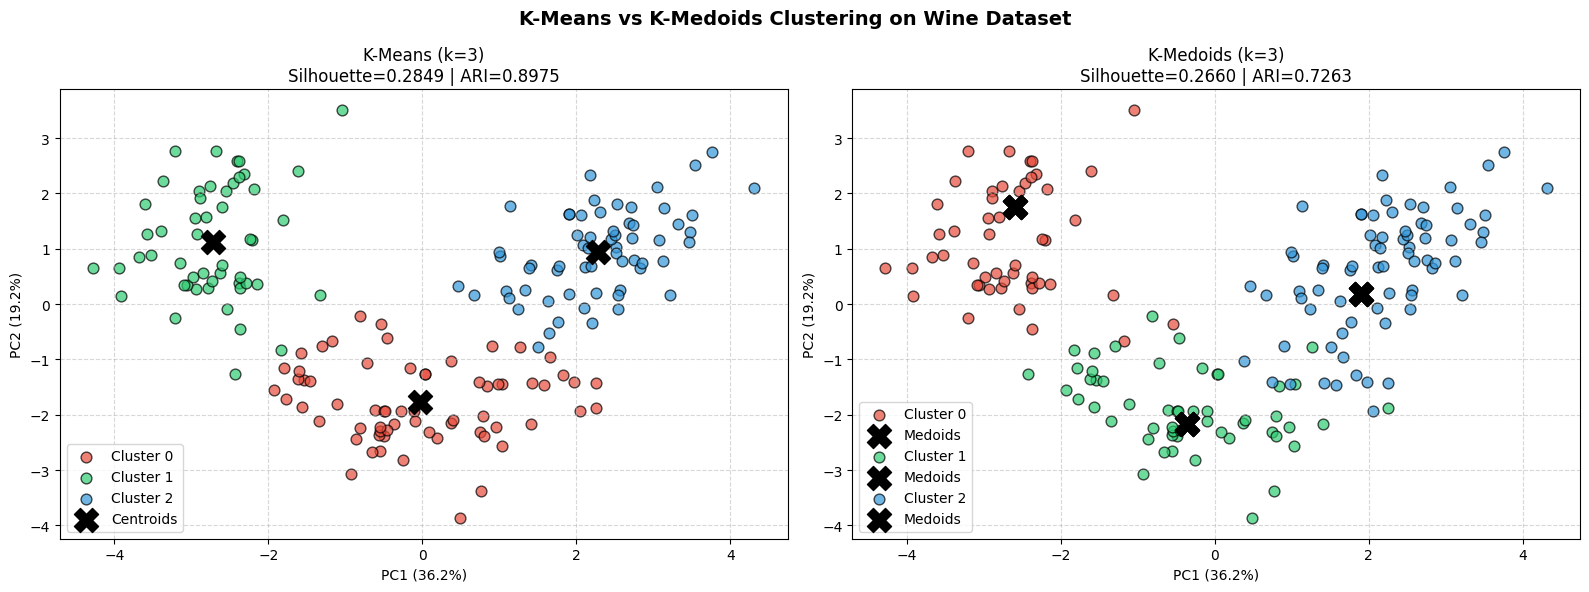

Metric                         K-Means    K-Medoids
Silhouette Score                0.2849       0.2660
Adjusted Rand Index             0.8975       0.7263


In [17]:
#Create side-by-side scatter plots for both the K-Means and K-Medoids clusters. 
#Mark the cluster centroids/medoids on the plots for visual clarity. 
#Provide a brief analysis comparing the results: 
#Which algorithm produced better-defined clusters? 
#What differences do you observe in cluster shapes or positioning? 
#Based on your results, explain when K-Means or K-Medoids may be preferable


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


# Transform centroids and medoids to PCA space
kmeans_centroids_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_medoids_pca = X_pca[kmedoids.medoid_indices_]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors      = ['#e74c3c', '#2ecc71', '#3498db']
label_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']


# K-Means
for i, (color, label) in enumerate(zip(colors, label_names)):
    mask = kmeans.labels_ == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label, alpha=0.7, edgecolors='k', s=60)

axes[0].scatter(kmeans_centroids_pca[:, 0], kmeans_centroids_pca[:, 1],
                c='black', marker='X', s=300, zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (k=3)\nSilhouette={sil_score:.4f} | ARI={ari_score:.4f}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# K-Medoids
for i, (color, label) in enumerate(zip(colors, label_names)):
    mask = kmedoids.labels_ == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label, alpha=0.7, edgecolors='k', s=60)



    axes[1].scatter(kmedoids_medoids_pca[:, 0], kmedoids_medoids_pca[:, 1],
                c='black', marker='X', s=300, zorder=5, label='Medoids')
axes[1].set_title(f'K-Medoids (k=3)\nSilhouette={sil_kmedoids:.4f} | ARI={ari_kmedoids:.4f}')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('K-Means vs K-Medoids Clustering on Wine Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



print("=" * 55)
print(f"{'Metric':<25} {'K-Means':>12} {'K-Medoids':>12}")
print("=" * 55)
print(f"{'Silhouette Score':<25} {sil_score:>12.4f} {sil_kmedoids:>12.4f}")
print(f"{'Adjusted Rand Index':<25} {ari_score:>12.4f} {ari_kmedoids:>12.4f}")
print("=" * 55)


 

#Analysis

Both Algorithms produced similar clusters. I would say that the K-Means Alorigthm produces better defined clusters.
From the Scatter plot you can see less intersections between clusters than in the K-Memoids algorithm
K-Means also has a slightly higher Silhouette score and Adjusted Rand Index.

Centroids in the K-Means cluster appear to converge at more central points in each cluster where as K-Memoids are not as central. 
In the Cluster 2 in K-memoids the cluster is more spreadout overlapping with where K-Means determins is actually cluster 0

In terms of what is best to use in which situation, K-means uses a Generated Mean value from the data while the Medoid uses an actual point. Depending on the data the mean may not exist or be best for defining clusters. I would say if the data has a mean that can articulate the true average of the data the K-Means would be best.



